<a href="https://colab.research.google.com/github/eeshahar/data-science/blob/main/Copy_of_Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

You would want to include a polynomial element because it would better fit the model which would help the accuracy. The benefit is that is can model non linear relationships and showcase interactions accurately.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

It may make make things a little complex to an outside viewer and be too complex for what the dataset actually is. It can also lead to overfitting and make predictions outside of the scope of the dataset

**Task3**:

What's the point of using b splines?

The poing of using b splines is that we can get the flexibility of polynomial regression with less overfitting.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

A gaussian process tries to find connections and relationships between the variables in a dataset and using multiple possible best predictors to create like a range of the best possible output curves

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:
!pip install git+https://github.com/pydata/xarray.git
!pip install bambi
!pip install preliz

In [3]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import xarray as xr
import bambi as bmb
import pymc as pm

In [4]:
howellData = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

In [ ]:
polynomial = bmb.Model("height ~ poly(weight, degree=4)", howellData)
idata_polynomial = polynomial.fit(log_likelihood=True)

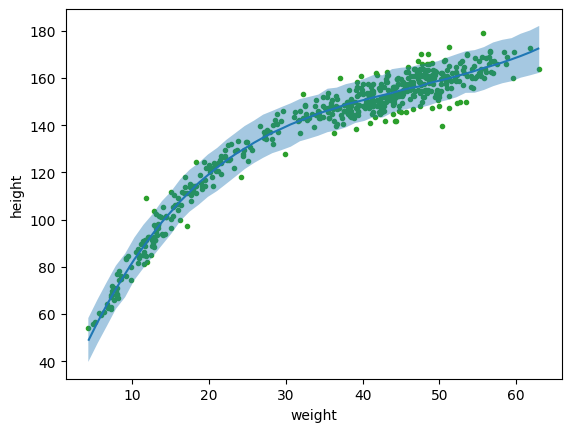

In [18]:
bmb.interpret.plot_predictions(polynomial, idata_polynomial, "weight", pps=True)
plt.plot(howellData.weight, howellData.height, "C2.", zorder=-3)

In [ ]:
num_knots = 6
knots = np.linspace(howellData["weight"].min(),
                    howellData["weight"].max(),
                    num_knots + 2)[1:-1]
spline = bmb.Model("height ~ bs(weight, degree=3, knots=knots)", howellData, family="negativebinomial")
idata_spline = spline.fit(log_likelihood=True)

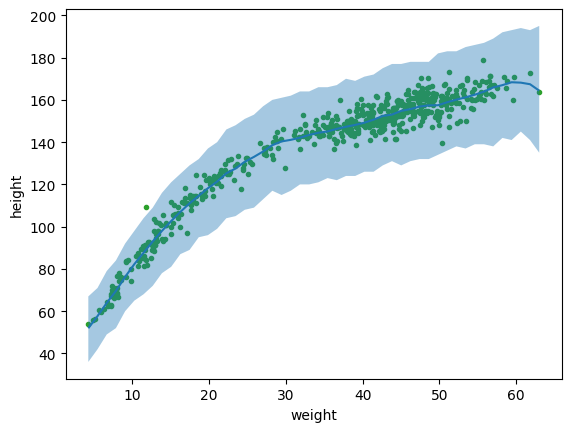

In [20]:
bmb.interpret.plot_predictions(spline, idata_spline, "weight", pps=True)
plt.plot(howellData.weight, howellData.height, "C2.", zorder=-3)

In [ ]:
gp_model = bmb.Model("height ~ (weight)", howellData)
idata_gp = gp_model.fit(log_likelihood=True)

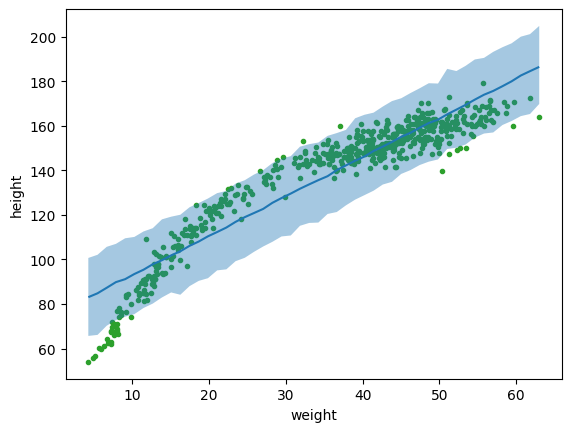

In [22]:
bmb.interpret.plot_predictions(gp_model, idata_gp, "weight", pps=True)
plt.plot(howellData.weight, howellData.height, "C2.", zorder=-3)

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

GPs are a lot more technical than B splines or polynomial models, in the sense that they involve a lot more things like hyperparameters and kernels that makes the actual code take longer and more complex. GPs are good for modeling continuous data sets versus discrete ones.

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

My favorite graph from the article is the Gaussian process model that relates Mauna Loa Carbon Dioxide combined with ice core data to predict long term trends. The black dots on the graph are the data points (whicch are ice core measurements) and there's a trend of CO2 rising exponentially right before 2000. The solid, darkest blue line through the middle of all the lighter blue thinner lines is the posterior prediction of the GP and the various shaded blue lines surrounding the posterior prediction are levels of uncertainty and other possible combinations